# Dry Run Analysis — Used Car Market Value Prediction

**Project:** Predicting Used Car Market Value from Vehicle Specifications and Listing Attributes  
**Team:** Team AutoVision

**Course** Advanced Machine Learning

**Team Lead** Aaish Faisal Hameedi (25k-7608)

**Team Member** Mehdi Abbas (25k-7601)

**Instructor** Sir Umair Hanif

This notebook is a lightweight dry run of the complete project pipeline.  
It uses small samples so that `Run All` works quickly while still demonstrating:

1. Dataset loading  
2. Data inspection  
3. Data cleaning  
4. Feature engineering  
5. Exploratory data analysis  
6. Model training  
7. Model evaluation  
8. Sample car price prediction  
9. Optional fair / overpriced / underpriced business layer  
10. PakWheels localized comparison idea

## 1. Environment Setup

This cell imports the required libraries, detects the project root, and confirms that the expected dataset folder exists.

In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Detect project root.
# In VS Code, notebooks sometimes run from project root and sometimes from notebooks/.
cwd = Path.cwd()
if (cwd / "dataset").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "dataset").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find dataset/ folder. Please run this notebook from CPP Project/ or CPP Project/notebooks/.")

DATASET_DIR = PROJECT_ROOT / "dataset"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Reports folder:", REPORTS_DIR)

Project root: d:\CPP Project
Dataset folder: d:\CPP Project\dataset
Reports folder: d:\CPP Project\reports


## 2. Helper Functions

These helper functions make the notebook safer for messy CSV files and reusable across TrueCar and PakWheels datasets.

In [3]:
def safe_read_csv(path: Path, nrows: int | None = None) -> pd.DataFrame:
    """Read a CSV safely. If malformed rows exist, retry with Python engine and skip bad lines."""
    try:
        return pd.read_csv(path, nrows=nrows, low_memory=False)
    except pd.errors.ParserError:
        print(f"[WARN] Parser error in {path.name}. Retrying with bad-line skipping...")
        return pd.read_csv(path, nrows=nrows, engine="python", on_bad_lines="skip")


def quick_audit(df: pd.DataFrame, name: str) -> None:
    """Print a compact dataset audit."""
    print("=" * 90)
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print("\nDuplicate rows:", df.duplicated().sum())
    if "Vin" in df.columns:
        print("Duplicate VINs:", df.duplicated(subset=["Vin"]).sum())
    print("=" * 90)

## 3. Load Dataset Samples

For the dry run, we load only small samples from the raw CSV files.  
The full project scripts already process the complete datasets, but this notebook is designed to run quickly.

In [4]:
truecar_01_path = DATASET_DIR / "true_car_listing_01.csv"
truecar_02_path = DATASET_DIR / "true_car_listings_02.csv"
pakwheels_path = DATASET_DIR / "pakwheels_pakistan_automobile_dataset.csv"

for path in [truecar_01_path, truecar_02_path, pakwheels_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

# Small samples for dry run
tc1 = safe_read_csv(truecar_01_path, nrows=50_000)
tc2 = safe_read_csv(truecar_02_path, nrows=50_000)
pw_raw = safe_read_csv(pakwheels_path, nrows=20_000)

print("Loaded samples successfully.")
print("TrueCar 01 sample:", tc1.shape)
print("TrueCar 02 sample:", tc2.shape)
print("PakWheels sample:", pw_raw.shape)

Loaded samples successfully.
TrueCar 01 sample: (50000, 9)
TrueCar 02 sample: (50000, 8)
PakWheels sample: (20000, 16)


## 4. Inspect Raw Dataset Samples

This cell checks the raw schema, missing values, duplicate rows, and VIN uniqueness.

In [5]:
quick_audit(tc1, "TrueCar Listing 01 Sample")
quick_audit(tc2, "TrueCar Listings 02 Sample")
quick_audit(pw_raw, "PakWheels Pakistan Automobile Sample")

Dataset: TrueCar Listing 01 Sample
Shape: (50000, 9)

Columns:
['Id', 'Price', 'Year', 'Mileage', 'City', 'State', 'Vin', 'Make', 'Model']

Data types:
Id          int64
Price       int64
Year        int64
Mileage     int64
City       object
State      object
Vin        object
Make       object
Model      object
dtype: object

Missing values:
Id         0
Price      0
Year       0
Mileage    0
City       0
State      0
Vin        0
Make       0
Model      0
dtype: int64

Duplicate rows: 0
Duplicate VINs: 0
Dataset: TrueCar Listings 02 Sample
Shape: (50000, 8)

Columns:
['Price', 'Year', 'Mileage', 'City', 'State', 'Vin', 'Make', 'Model']

Data types:
Price       int64
Year        int64
Mileage     int64
City       object
State      object
Vin        object
Make       object
Model      object
dtype: object

Missing values:
Price      0
Year       0
Mileage    0
City       0
State      0
Vin        0
Make       0
Model      0
dtype: int64

Duplicate rows: 0
Duplicate VINs: 0
Dataset: Pak

## 5. Merge and Clean TrueCar Sample

The first TrueCar file contains an extra `Id` column, so we remove it before merging.  
Then we remove duplicate VINs and apply basic domain filters for price, mileage, and year.

In [6]:
# Standardize column names
tc1.columns = [col.strip() for col in tc1.columns]
tc2.columns = [col.strip() for col in tc2.columns]

# Drop Id from file 1 so both TrueCar files align
if "Id" in tc1.columns:
    tc1 = tc1.drop(columns=["Id"])

# Clean string columns
for df in [tc1, tc2]:
    for col in ["City", "State", "Vin", "Make", "Model"]:
        df[col] = df[col].astype(str).str.strip()

# Merge samples
truecar = pd.concat([tc1, tc2], ignore_index=True)

before_dedup = len(truecar)
truecar = truecar.drop_duplicates(subset=["Vin"], keep="first").reset_index(drop=True)
after_dedup = len(truecar)

# Convert numeric columns
for col in ["Price", "Year", "Mileage"]:
    truecar[col] = pd.to_numeric(truecar[col], errors="coerce")

# Drop missing key values
truecar = truecar.dropna(subset=["Price", "Year", "Mileage", "Vin", "Make", "Model"])

# Domain filters
truecar = truecar[
    (truecar["Price"] > 500) &
    (truecar["Price"] < 250000) &
    (truecar["Mileage"] >= 0) &
    (truecar["Mileage"] < 500000) &
    (truecar["Year"] >= 1990) &
    (truecar["Year"] <= 2026)
].copy()

print(f"Rows before VIN deduplication: {before_dedup}")
print(f"Rows after VIN deduplication : {after_dedup}")
print("Cleaned TrueCar sample shape:", truecar.shape)

display(truecar.head())

Rows before VIN deduplication: 100000
Rows after VIN deduplication : 99671
Cleaned TrueCar sample shape: (99659, 8)


,Price,Year,Mileage,City,State,Vin,Make,Model
0,16472,2015,18681,Jefferson City,MO,KL4CJBSBXFB267643,Buick,EncoreConvenience
1,15749,2015,27592,Highland,IN,KL4CJASB5FB245057,Buick,EncoreFWD
2,16998,2015,13650,Boone,NC,KL4CJCSB0FB264921,Buick,EncoreLeather
3,15777,2015,25195,New Orleans,LA,KL4CJASB4FB217542,Buick,EncoreFWD
4,16784,2015,22800,Las Vegas,NV,KL4CJBSB3FB166881,Buick,EncoreConvenience


## 6. Feature Engineering

Here we create the same core engineered features used in the main implementation:

- `VehicleAge`
- `MileagePerYear`
- `LogPrice`
- `LogMileage`
- `MakeModel`
- `AgeBucket`
- `MileageBucket`

In [7]:
# Use dataset-based reference year to avoid artificially aging the cars.
dataset_reference_year = int(truecar["Year"].max()) + 1

truecar["VehicleAge"] = dataset_reference_year - truecar["Year"]
truecar["VehicleAge"] = truecar["VehicleAge"].clip(lower=1)

truecar["MileagePerYear"] = truecar["Mileage"] / truecar["VehicleAge"]
truecar["LogPrice"] = np.log1p(truecar["Price"])
truecar["LogMileage"] = np.log1p(truecar["Mileage"])
truecar["MakeModel"] = truecar["Make"] + "_" + truecar["Model"]

truecar["AgeBucket"] = pd.cut(
    truecar["VehicleAge"],
    bins=[0, 2, 5, 10, 20, 100],
    labels=["0-2 years", "3-5 years", "6-10 years", "11-20 years", "20+ years"],
    include_lowest=True
)

truecar["MileageBucket"] = pd.cut(
    truecar["Mileage"],
    bins=[-1, 25000, 60000, 100000, 150000, 500000],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

print("Reference year used:", dataset_reference_year)
print("Feature-engineered TrueCar sample shape:", truecar.shape)
display(truecar[["Price", "Year", "Mileage", "VehicleAge", "MileagePerYear", "Make", "Model", "MakeModel"]].head())

Reference year used: 2019
Feature-engineered TrueCar sample shape: (99659, 15)


,Price,Year,Mileage,VehicleAge,MileagePerYear,Make,Model,MakeModel
0,16472,2015,18681,4,4670.25,Buick,EncoreConvenience,Buick_EncoreConvenience
1,15749,2015,27592,4,6898.00,Buick,EncoreFWD,Buick_EncoreFWD
2,16998,2015,13650,4,3412.50,Buick,EncoreLeather,Buick_EncoreLeather
3,15777,2015,25195,4,6298.75,Buick,EncoreFWD,Buick_EncoreFWD
4,16784,2015,22800,4,5700.00,Buick,EncoreConvenience,Buick_EncoreConvenience


## 7. Exploratory Data Analysis — Target and Numerical Features

These visualizations check price distribution, mileage effect, and vehicle age effect.

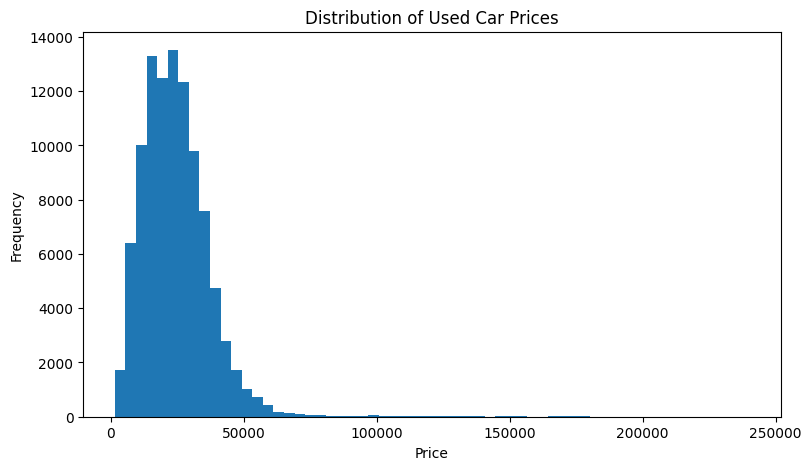

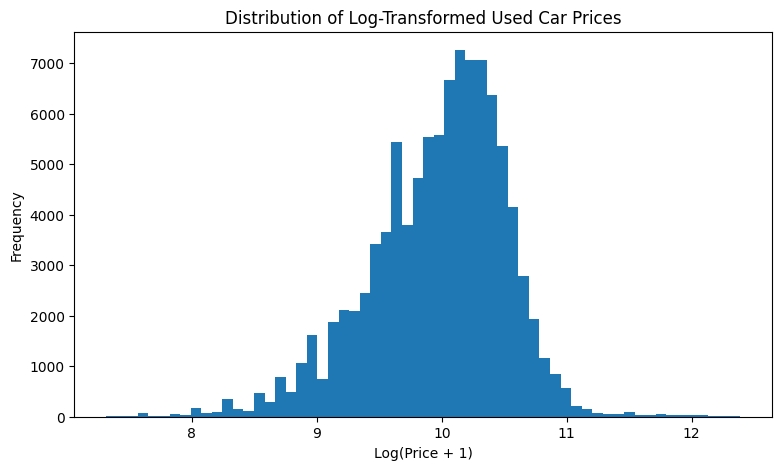

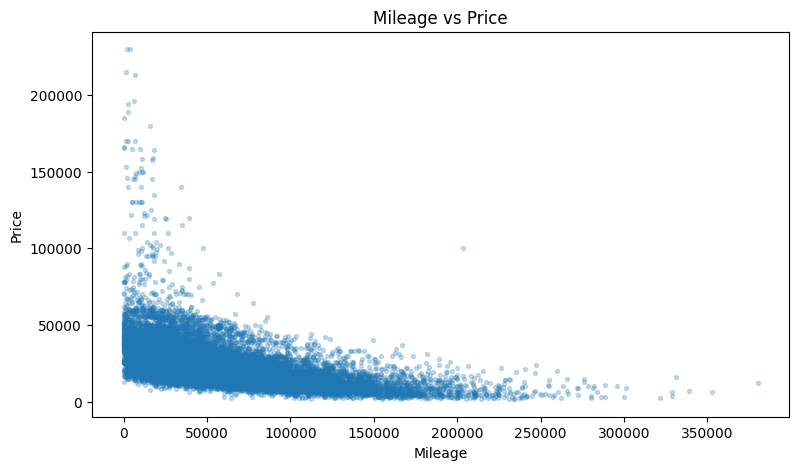

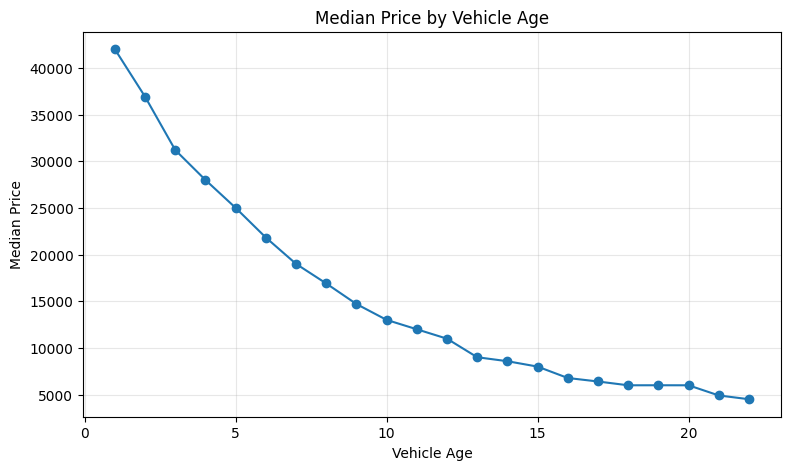

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(truecar["Price"], bins=60)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(truecar["LogPrice"], bins=60)
plt.title("Distribution of Log-Transformed Used Car Prices")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

plot_sample = truecar.sample(min(20_000, len(truecar)), random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(plot_sample["Mileage"], plot_sample["Price"], alpha=0.25, s=8)
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

age_price = truecar.groupby("VehicleAge", as_index=False)["Price"].median()
age_price = age_price[age_price["VehicleAge"] <= 25]

plt.figure(figsize=(9, 5))
plt.plot(age_price["VehicleAge"], age_price["Price"], marker="o")
plt.title("Median Price by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Median Price")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Exploratory Data Analysis — Categorical Features

This checks which makes appear most often and how median price varies across top makes.

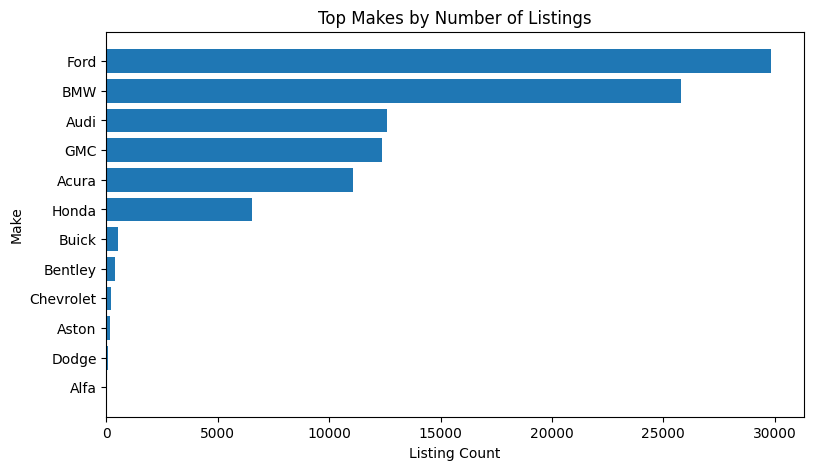

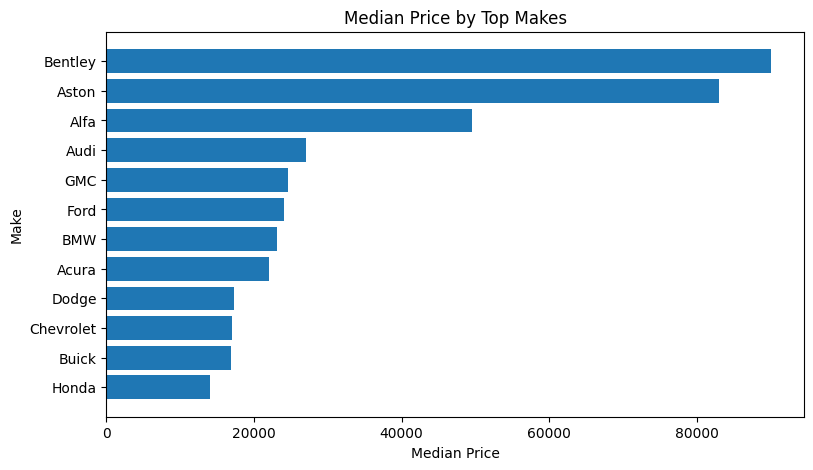

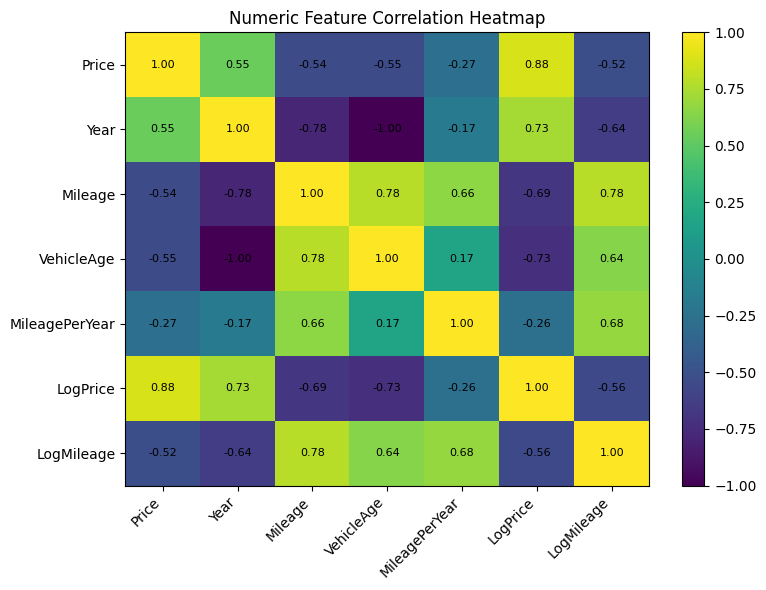

In [9]:
top_makes = truecar["Make"].value_counts().head(12)

plt.figure(figsize=(9, 5))
plt.barh(top_makes.index[::-1], top_makes.values[::-1])
plt.title("Top Makes by Number of Listings")
plt.xlabel("Listing Count")
plt.ylabel("Make")
plt.show()

top_make_names = top_makes.index.tolist()
make_price = (
    truecar[truecar["Make"].isin(top_make_names)]
    .groupby("Make")["Price"]
    .median()
    .sort_values()
)

plt.figure(figsize=(9, 5))
plt.barh(make_price.index, make_price.values)
plt.title("Median Price by Top Makes")
plt.xlabel("Median Price")
plt.ylabel("Make")
plt.show()

numeric_cols = ["Price", "Year", "Mileage", "VehicleAge", "MileagePerYear", "LogPrice", "LogMileage"]
corr = truecar[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numeric Feature Correlation Heatmap")
plt.colorbar()
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Dry Run Model Training

This cell trains a few lightweight regression models on the sampled TrueCar data.

Main task: **predict used-car price**, so the correct metrics are:

- MAE
- RMSE
- R²

In [10]:
FEATURES = [
    "Year",
    "Mileage",
    "VehicleAge",
    "MileagePerYear",
    "LogMileage",
    "City",
    "State",
    "Make",
    "Model",
    "MakeModel",
]

TARGET = "Price"

NUMERIC_FEATURES = [
    "Year",
    "Mileage",
    "VehicleAge",
    "MileagePerYear",
    "LogMileage",
]

CATEGORICAL_FEATURES = [
    "City",
    "State",
    "Make",
    "Model",
    "MakeModel",
]

model_df = truecar[FEATURES + [TARGET]].dropna().copy()
model_df = model_df.sample(min(50_000, len(model_df)), random_state=42).reset_index(drop=True)

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, NUMERIC_FEATURES),
        ("cat", categorical_preprocessor, CATEGORICAL_FEATURES),
    ]
)

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=120,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        max_depth=16,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
}

results = []
trained_models = {}

for name, regressor in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", regressor),
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best dry-run model:", best_model_name)

,Model,MAE,RMSE,R2
1,Hist Gradient Boosting,3009.83,4953.77,0.8694
2,Random Forest,2926.22,5160.38,0.8583
0,Ridge Regression,6673.70,10793.96,0.3802


Best dry-run model: Hist Gradient Boosting


## 10. Model Evaluation Visualizations

These plots show actual vs predicted price and residual behavior for the best dry-run model.

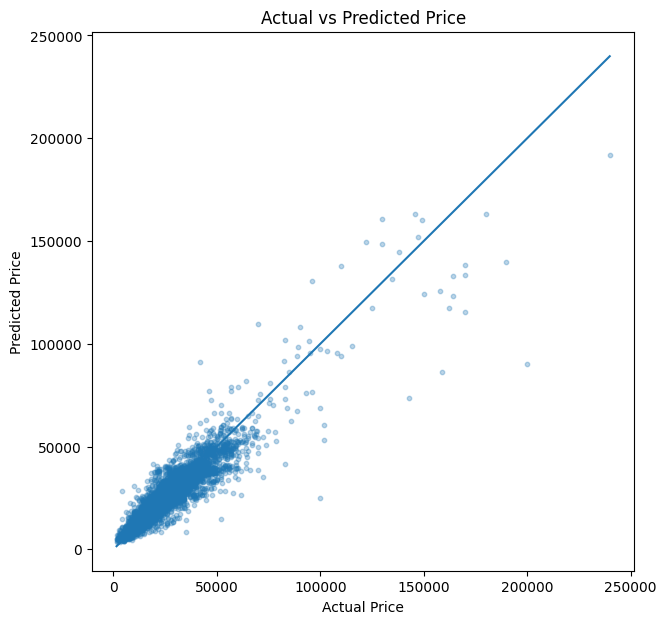

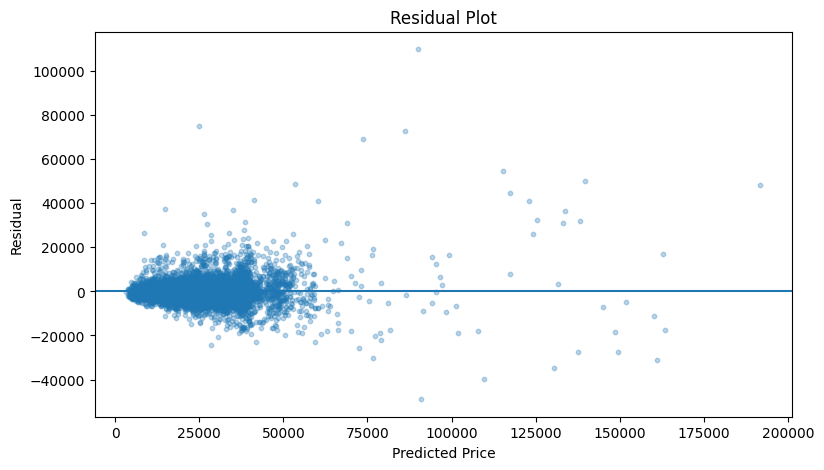

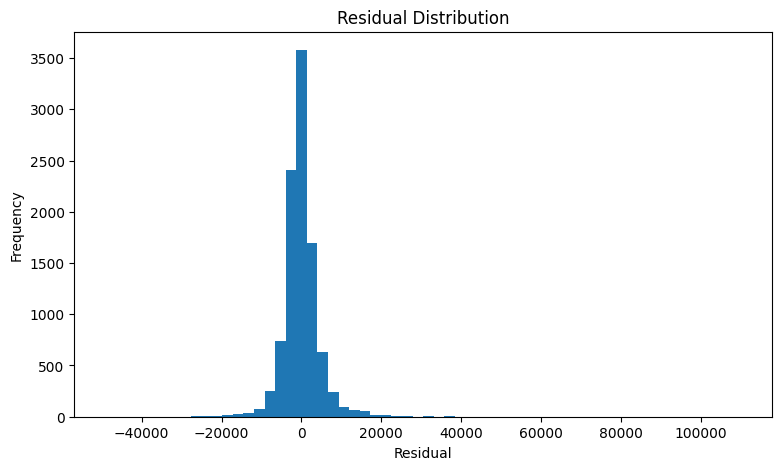

In [11]:
best_preds = best_model.predict(X_test)
eval_df = pd.DataFrame({
    "ActualPrice": y_test.values,
    "PredictedPrice": best_preds,
})
eval_df["Residual"] = eval_df["ActualPrice"] - eval_df["PredictedPrice"]

plot_eval = eval_df.sample(min(10_000, len(eval_df)), random_state=42)

plt.figure(figsize=(7, 7))
plt.scatter(plot_eval["ActualPrice"], plot_eval["PredictedPrice"], alpha=0.3, s=10)
min_val = min(plot_eval["ActualPrice"].min(), plot_eval["PredictedPrice"].min())
max_val = max(plot_eval["ActualPrice"].max(), plot_eval["PredictedPrice"].max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(plot_eval["PredictedPrice"], plot_eval["Residual"], alpha=0.3, s=10)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(plot_eval["Residual"], bins=60)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## 11. One Car Price Prediction

This is a simple example showing how the trained model can predict the fair market value for a single car listing.

In [12]:
sample_car = pd.DataFrame([
    {
        "Year": 2017,
        "Mileage": 35000,
        "VehicleAge": dataset_reference_year - 2017,
        "MileagePerYear": 35000 / max(dataset_reference_year - 2017, 1),
        "LogMileage": np.log1p(35000),
        "City": "Houston",
        "State": "TX",
        "Make": "Toyota",
        "Model": "Camry",
        "MakeModel": "Toyota_Camry",
    }
])

predicted_price = best_model.predict(sample_car)[0]

display(sample_car)
print(f"Predicted fair market value: {predicted_price:,.2f}")

,Year,Mileage,VehicleAge,MileagePerYear,LogMileage,City,State,Make,Model,MakeModel
0,2017,35000,2,17500.0,10.463132,Houston,TX,Toyota,Camry,Toyota_Camry


Predicted fair market value: 22,688.92


## 12. Optional Business Layer — Fair / Underpriced / Overpriced

This converts the regression prediction into a decision-support layer.

Rule:
- Underpriced: listed price is more than 10% below predicted fair value
- Fair: listed price is within ±10% of predicted fair value
- Overpriced: listed price is more than 10% above predicted fair value

,Year,Mileage,Make,Model,ActualPrice,PredictedFairValue,PricePosition
33553,2010,93441,BMW,5,13881,14170.840839,Fair
9427,2014,54586,Ford,ExplorerLimited,28997,25386.162368,Overpriced
199,2015,43349,Audi,A3Sedan,20700,21708.775775,Fair
12447,2013,93378,Honda,Civic,8995,10623.679815,Underpriced
39489,2009,110729,BMW,5,9328,11528.229443,Underpriced
42724,2011,63068,BMW,X5AWD,18950,19443.013151,Fair
10822,2016,21169,Honda,Accord,17500,18067.366338,Fair
49498,2014,26433,Honda,Civic,15854,14217.907482,Overpriced
4144,2017,3847,BMW,X3xDrive28i,43975,40842.468620,Fair
36958,2006,138488,Ford,F-1502WD,10500,9416.196745,Overpriced


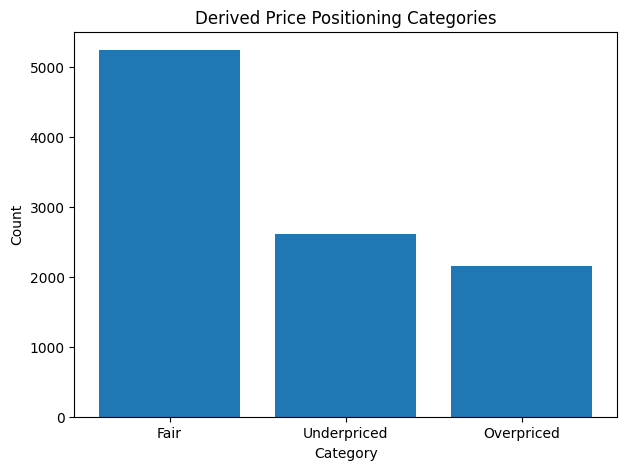

In [13]:
def price_position(actual_price: float, predicted_fair_value: float, tolerance: float = 0.10) -> str:
    ratio = (actual_price - predicted_fair_value) / predicted_fair_value

    if ratio > tolerance:
        return "Overpriced"
    if ratio < -tolerance:
        return "Underpriced"
    return "Fair"

business_df = X_test.copy()
business_df["ActualPrice"] = y_test.values
business_df["PredictedFairValue"] = best_preds
business_df["PricePosition"] = [
    price_position(actual, pred)
    for actual, pred in zip(business_df["ActualPrice"], business_df["PredictedFairValue"])
]

display(business_df[["Year", "Mileage", "Make", "Model", "ActualPrice", "PredictedFairValue", "PricePosition"]].head(10))

position_counts = business_df["PricePosition"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(position_counts.index, position_counts.values)
plt.title("Derived Price Positioning Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## 13. PakWheels Localized Extension — Cleaning Sample

PakWheels is not merged directly with TrueCar because both datasets belong to different markets and currencies.  
Instead, it is used for a localized comparison of depreciation behavior.

In [14]:
pw = pw_raw.copy()
pw.columns = [col.strip() for col in pw.columns]

rename_map = {
    "title": "Title",
    "price": "Price",
    "city": "City",
    "model": "Year",
    "mileage": "Mileage",
    "fuel_type": "FuelType",
    "transmission": "Transmission",
    "registered": "Registered",
    "color": "Color",
    "assembly": "Assembly",
    "engine_capacity": "EngineCapacity",
    "post_date": "PostDate",
    "price_category": "PriceCategory",
    "mileage_category": "MileageCategory",
    "post_day_of_week": "PostDayOfWeek",
    "vehicle_age": "VehicleAgeProvided",
}

pw = pw.rename(columns=rename_map)

for col in ["Price", "Year", "Mileage", "EngineCapacity"]:
    pw[col] = pd.to_numeric(pw[col], errors="coerce")

for col in ["Title", "City", "FuelType", "Transmission", "Registered", "Color", "Assembly", "PostDate"]:
    pw[col] = pw[col].astype(str).str.strip()

pw = pw.dropna(subset=["Price", "Year", "Mileage", "Title", "City"])
pw = pw.drop_duplicates()

pw = pw[
    (pw["Price"] > 50000) &
    (pw["Price"] < 100000000) &
    (pw["Mileage"] >= 0) &
    (pw["Mileage"] < 1000000) &
    (pw["Year"] >= 1990) &
    (pw["Year"] <= 2026)
].copy()

pw["PostDateParsed"] = pd.to_datetime(pw["PostDate"], errors="coerce")
pak_reference_year = 2024

pw["VehicleAge"] = (pak_reference_year - pw["Year"]).clip(lower=1)
pw["MileagePerYear"] = pw["Mileage"] / pw["VehicleAge"]
pw["LogMileage"] = np.log1p(pw["Mileage"])
pw["Make"] = pw["Title"].apply(lambda x: str(x).split()[0] if str(x).strip() else "Unknown")
pw["Market"] = "Pakistan"

print("Cleaned PakWheels sample shape:", pw.shape)
display(pw[["Title", "Price", "Year", "Mileage", "VehicleAge", "MileagePerYear", "City", "Make"]].head())

Cleaned PakWheels sample shape: (19596, 22)


,Title,Price,Year,Mileage,VehicleAge,MileagePerYear,City,Make
0,Honda N One Premium 2014,2650000,2014,82000,10,8200.000000,Lahore,Honda
1,Nissan Note 2020,5400000,2020,59000,4,14750.000000,Lahore,Nissan
3,Toyota Yaris Cross 2021,7850000,2021,41000,3,13666.666667,Lahore,Toyota
4,BMW X1 sDrive18i 2017,10700000,2017,37000,7,5285.714286,Islamabad,BMW
5,Honda City Aspire Prosmatec 1.5 i-VTEC 2016,3600000,2016,45000,8,5625.000000,Karachi,Honda


## 14. Cross-Market Depreciation Comparison

Since TrueCar prices are in USD and PakWheels prices are in PKR, raw prices should not be compared directly.

Instead, we use:

`PriceIndex = Vehicle Price / Market Median Price`

This normalizes each market internally and makes depreciation trends more comparable.

,Market,VehicleAge,MedianPriceIndex,MedianMileage,Count
0,Pakistan,1,2.142857,4700.0,906
1,Pakistan,2,1.512714,21000.0,1740
2,Pakistan,3,1.400000,35000.0,2014
3,Pakistan,4,1.300000,42000.0,1662
4,Pakistan,5,1.271429,59000.0,1197
5,Pakistan,6,1.282857,70000.0,1534
6,Pakistan,7,1.107143,80000.0,1207
7,Pakistan,8,1.028571,88000.0,858
8,Pakistan,9,0.957143,95000.0,896
9,Pakistan,10,0.900000,100000.0,853


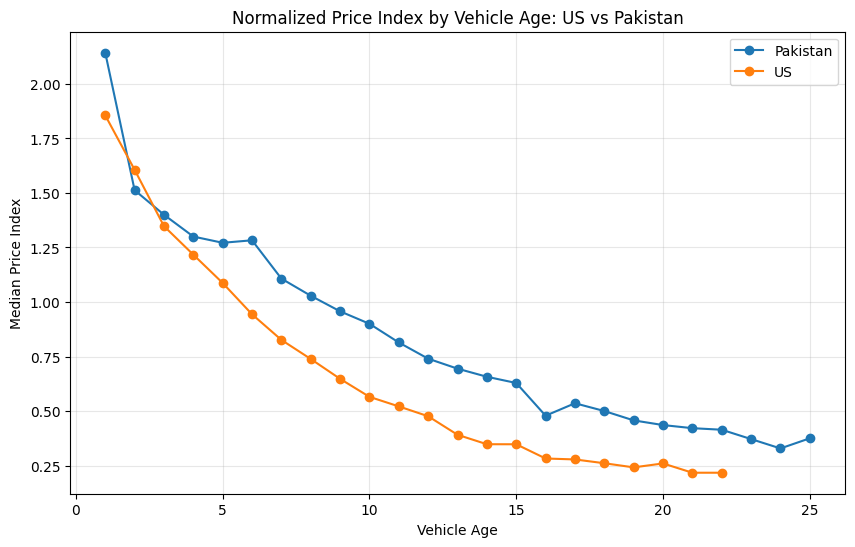

,Market,MedianVehicleAge,MedianMileage,MedianMileagePerYear,Records
0,Pakistan,7.0,72000.0,9428.571429,19596
1,US,5.0,43490.5,8258.708791,50000


In [15]:
us_compare = truecar[["Price", "Year", "VehicleAge", "Mileage", "MileagePerYear", "Make"]].copy()
us_compare["Market"] = "US"

pk_compare = pw[["Price", "Year", "VehicleAge", "Mileage", "MileagePerYear", "Make"]].copy()
pk_compare["Market"] = "Pakistan"

# Sample US for balanced dry-run visualization
us_compare = us_compare.sample(min(50_000, len(us_compare)), random_state=42)

market_compare = pd.concat([us_compare, pk_compare], ignore_index=True)

market_compare["PriceIndex"] = (
    market_compare["Price"] / market_compare.groupby("Market")["Price"].transform("median")
)

age_summary = (
    market_compare
    .groupby(["Market", "VehicleAge"], as_index=False)
    .agg(
        MedianPriceIndex=("PriceIndex", "median"),
        MedianMileage=("Mileage", "median"),
        Count=("Price", "size")
    )
)

display(age_summary.head(10))

plot_age_summary = age_summary[
    (age_summary["VehicleAge"] <= 25) &
    (age_summary["Count"] >= 20)
]

plt.figure(figsize=(10, 6))
for market, group in plot_age_summary.groupby("Market"):
    plt.plot(group["VehicleAge"], group["MedianPriceIndex"], marker="o", label=market)

plt.title("Normalized Price Index by Vehicle Age: US vs Pakistan")
plt.xlabel("Vehicle Age")
plt.ylabel("Median Price Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

market_summary = market_compare.groupby("Market").agg(
    MedianVehicleAge=("VehicleAge", "median"),
    MedianMileage=("Mileage", "median"),
    MedianMileagePerYear=("MileagePerYear", "median"),
    Records=("Price", "size")
).reset_index()

display(market_summary)

## 15. Dry Run Summary

This notebook has demonstrated the project end-to-end on smaller samples:

- Loaded TrueCar and PakWheels CSV files
- Inspected schemas and quality
- Cleaned and merged TrueCar samples
- Engineered useful vehicle pricing features
- Performed EDA and data visualization
- Trained regression models
- Evaluated model performance
- Predicted a single car price
- Built a fair / underpriced / overpriced layer
- Demonstrated localized US vs Pakistan depreciation comparison

In [17]:
summary = {
    "TrueCar dry-run rows": len(truecar),
    "PakWheels dry-run rows": len(pw),
    "Best dry-run model": best_model_name,
    "Best dry-run RMSE": float(results_df.iloc[0]["RMSE"]),
    "Best dry-run R2": float(results_df.iloc[0]["R2"]),
    "Sample car predicted price": round(float(predicted_price), 2),
}

summary_df = pd.DataFrame(summary.items(), columns=["Item", "Value"])
display(summary_df)


,Item,Value
0,TrueCar dry-run rows,99659
1,PakWheels dry-run rows,19596
2,Best dry-run model,Hist Gradient Boosting
3,Best dry-run RMSE,4953.77
4,Best dry-run R2,0.8694
5,Sample car predicted price,22688.92
